# Regular Scenario – Fingerprint Method 1

**Scene:** Plaza Mayor, Madrid – a symmetric open square with 4 transmitters at the corners (z=20m).

**Method 1:** Fingerprint based on **channel gain only** (one value per TX in dB). Position estimation uses kNN with Euclidean distance.

This scenario represents an ideal LOS-dominated environment where channel gain alone is expected to provide good spatial discrimination.

## 1. Environment Setup
Install required dependencies.

In [1]:
# Celda 1: Instalar dependencias
!apt-get update
!apt-get install -y llvm
!pip install sionna-rt

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:2 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2378 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]     
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [39.2 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:9 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3737 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4096 kB]
Get:12 http://archive.ubuntu.com/u

In [2]:
!pip uninstall sionna-rt -y
!pip install --upgrade pip

!pip install sionna-rt
!pip install scikit-learn


Found existing installation: sionna-rt 1.2.1
Uninstalling sionna-rt-1.2.1:
  Successfully uninstalled sionna-rt-1.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.3 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
  Using cached sionna_rt-1.2.1-py3-none-any.whl.metadata (4.8 kB)
Using cached sionna_rt-1.2.1-py3-none-any.whl (8.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 26.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


## 2. Library Imports
Import Sionna RT, NumPy, Matplotlib, and other required modules.

In [3]:
# después de reiniciar
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold



no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# (Aquí puedes continuar con el resto de tu código)
print("¡Sionna RT importado con éxito!")

¡Sionna RT importado con éxito!


## 3. Antenna Configuration
Define transmitter (TR38.901) and receiver (dipole, cross-polarized) antenna arrays.

In [4]:
# Configure antenna array for all transmitters
tx_array_config  = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",  #tr38901
                             polarization="V")

# Configure antenna array for all receivers
rx_array_config = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",  #dipole
                             polarization="cross") #cross

## 4. Path Solver Configuration
Set ray tracing parameters. The `max_depth` parameter is changed manually between executions to evaluate LOS, NLOS1, NLOS2, and NLOS6 conditions.

In [5]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
solver_params = dict(
                 max_depth=10, #max numero de rebotes permitidos
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

## 5. Load 3D Scene
Import the Mitsuba/Sionna scene file for the scenario.

In [6]:
scene= load_scene("PlazaMayor2/PlazaMayor2.xml", merge_shapes=True) # Merge shapes to speed-up computations

## 6. Transmitter Placement
Place transmitters at fixed positions in the regular (Plaza Mayor) scenario.

In [7]:
scene.tx_array = tx_array_config
scene.rx_array = rx_array_config


np.random.seed(42) 

tx = Transmitter(name="tx",
                position=[-18, 27, 20],
                display_radius=2)
tx1 = Transmitter(name="tx1",
                 position=[18, 27, 20],
                 display_radius=2)
tx2 = Transmitter(name="tx2",
                position=[-18, -27, 20],
                display_radius=2)
tx3 = Transmitter(name="tx3",
                 position=[18, -27, 20],
                 display_radius=2)

# [18, -37, 26]


scene.add(tx)
scene.add(tx1)
scene.add(tx2)
scene.add(tx3)


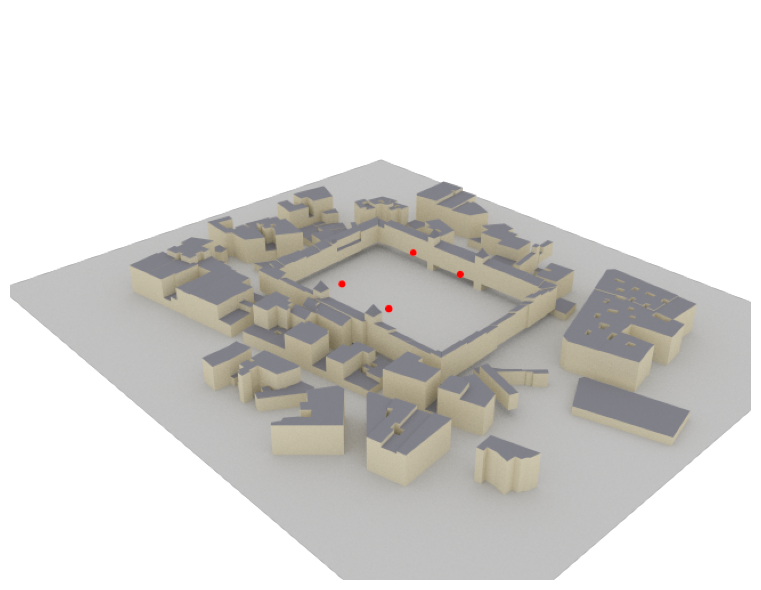

In [14]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-300,300,250], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

LA REGION DENTRO DE LA PLAZA MAYOR ESTA ACOTADA POR LOS 4 PUNTOS DE COORDENADAS: </BR>
[-50, -37, 26] </BR>
[50, -37, 26]</BR>
[-50, 37, 26]</BR>
[50, 37, 26]</BR>

[-18, -27, 20]


GRID SEARCH

Con paso_xy = 3 m:

X → 21 puntos

Y → 16 puntos

Z → 2 niveles

👉 21 × 16 × 2 = 672 receptores

Posicion 1 a estimar (0.0, 0.0, 1.5)

### GRID SEARCH. RECEPTORES TRAINING RX_GRID

## 7. Training Grid (Reference Receivers)
Create a uniform grid of receivers spaced 3m apart. These serve as the fingerprint database for position estimation.

In [8]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver
np.random.seed(42) 
# =======================================
# Rejilla 3D con SOLO 2 niveles en Z
# =======================================
def crear_rejilla_2_niveles_z(
    escena,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx"
):
    # Coordenadas X, Y uniformes
    x_coords = np.arange(x_lim[0], x_lim[1] + paso_xy, paso_xy)
    y_coords = np.arange(y_lim[0], y_lim[1] + paso_xy, paso_xy)

    receptores = []
    idx = 0

    for z in z_levels:
        for x in x_coords:
            for y in y_coords:
                pos = mi.Point3f(float(x), float(y), float(z))
                rx = Receiver(
                    name=f"{nombre_base}_{idx}",
                    position=pos,
                    display_radius=0.5
                )
                escena.add(rx)
                receptores.append(rx)
                idx += 1

    return receptores

# =======================================
# Definición del espacio
# =======================================
x_lim = [-25, 25]
y_lim = [-17, 17]

# SOLO DOS NIVELES EN Z
z_levels = [1.5]

paso_xy = 3.0  # separación en X e Y (metros)

# Crear receptores
receptores_grid = crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx_grid"
)

print(f"\n✔ Receptores creados: {len(receptores_grid)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_grid[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")



✔ Receptores creados: 234

Ejemplo de receptores:
R000: (-25.0, -17.0, 1.5)
R001: (-25.0, -14.0, 1.5)
R002: (-25.0, -11.0, 1.5)
R003: (-25.0, -8.0, 1.5)
R004: (-25.0, -5.0, 1.5)
R005: (-25.0, -2.0, 1.5)
R006: (-25.0, 1.0, 1.5)
R007: (-25.0, 4.0, 1.5)
R008: (-25.0, 7.0, 1.5)
R009: (-25.0, 10.0, 1.5)
R010: (-25.0, 13.0, 1.5)
R011: (-25.0, 16.0, 1.5)
R012: (-25.0, 19.0, 1.5)
R013: (-22.0, -17.0, 1.5)
R014: (-22.0, -14.0, 1.5)
R015: (-22.0, -11.0, 1.5)
R016: (-22.0, -8.0, 1.5)
R017: (-22.0, -5.0, 1.5)
R018: (-22.0, -2.0, 1.5)
R019: (-22.0, 1.0, 1.5)
R020: (-22.0, 4.0, 1.5)
R021: (-22.0, 7.0, 1.5)
R022: (-22.0, 10.0, 1.5)
R023: (-22.0, 13.0, 1.5)
R024: (-22.0, 16.0, 1.5)
R025: (-22.0, 19.0, 1.5)
R026: (-19.0, -17.0, 1.5)
R027: (-19.0, -14.0, 1.5)
R028: (-19.0, -11.0, 1.5)
R029: (-19.0, -8.0, 1.5)
R030: (-19.0, -5.0, 1.5)
R031: (-19.0, -2.0, 1.5)
R032: (-19.0, 1.0, 1.5)
R033: (-19.0, 4.0, 1.5)
R034: (-19.0, 7.0, 1.5)
R035: (-19.0, 10.0, 1.5)
R036: (-19.0, 13.0, 1.5)
R037: (-19.0, 16.0, 1.5)

### RECEPTORES A ESTIMAR. RECEPTORES TESTING: RX_TEST

## 8. Test Receivers (Unknown Positions)
100 receivers at random positions within the same area. Their positions will be estimated using fingerprinting.

In [9]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver

np.random.seed(123)

num_test_rx = 100
receptores_test = []

for i in range(num_test_rx):
    x = np.random.uniform(x_lim[0], x_lim[1])
    y = np.random.uniform(y_lim[0], y_lim[1])
    z = 1.5

    rx = Receiver(
        name=f"rx_test_{i}",
        position=mi.Point3f(float(x), float(y), float(z)),
        display_radius=0.5
    )
    scene.add(rx)
    receptores_test.append(rx)

print(f"\n✔ Receptores a estimar test creados: {len(receptores_test)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_test[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")


✔ Receptores a estimar test creados: 100

Ejemplo de receptores:
R000: (9.8, -7.3, 1.5)
R001: (-13.7, 1.7, 1.5)
R002: (11.0, -2.6, 1.5)
R003: (24.0, 6.3, 1.5)
R004: (-1.0, -3.7, 1.5)
R005: (-7.8, 7.8, 1.5)
R006: (-3.1, -15.0, 1.5)
R007: (-5.1, 8.1, 1.5)
R008: (-15.9, -11.0, 1.5)
R009: (1.6, 1.1, 1.5)
R010: (6.7, 11.9, 1.5)
R011: (11.2, 3.8, 1.5)
R012: (11.1, -6.0, 1.5)
R013: (-6.9, -9.2, 1.5)
R014: (-10.3, 4.5, 1.5)
R015: (-20.4, -2.3, 1.5)
R016: (-3.5, -0.2, 1.5)
R017: (-3.7, -6.4, 1.5)
R018: (-3.7, 13.4, 1.5)
R019: (22.2, 0.1, 1.5)
R020: (6.2, -13.1, 1.5)
R021: (-9.1, -2.9, 1.5)
R022: (18.3, -8.5, 1.5)
R023: (-0.8, 16.5, 1.5)
R024: (1.0, 3.8, 1.5)
R025: (-19.0, 11.1, 1.5)
R026: (5.2, 1.5, 1.5)
R027: (-7.9, -6.7, 1.5)
R028: (-4.1, 6.2, 1.5)
R029: (18.8, 0.4, 1.5)
R030: (8.5, 2.9, 1.5)
R031: (6.2, 5.9, 1.5)
R032: (17.1, -14.2, 1.5)
R033: (13.2, -8.7, 1.5)
R034: (-15.3, 2.5, 1.5)
R035: (-20.2, 13.1, 1.5)
R036: (6.4, 7.6, 1.5)
R037: (-24.2, 3.2, 1.5)
R038: (2.8, -11.6, 1.5)
R039: (-17.3

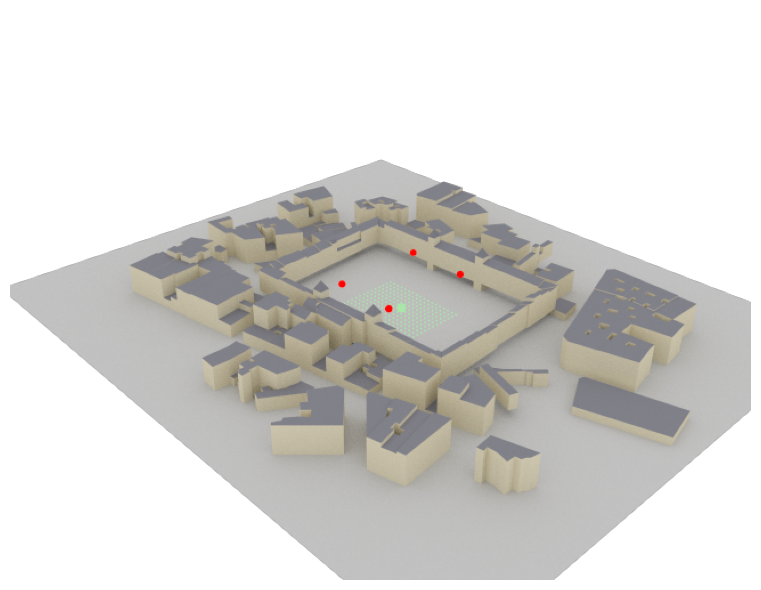

In [25]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-300,300,250], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

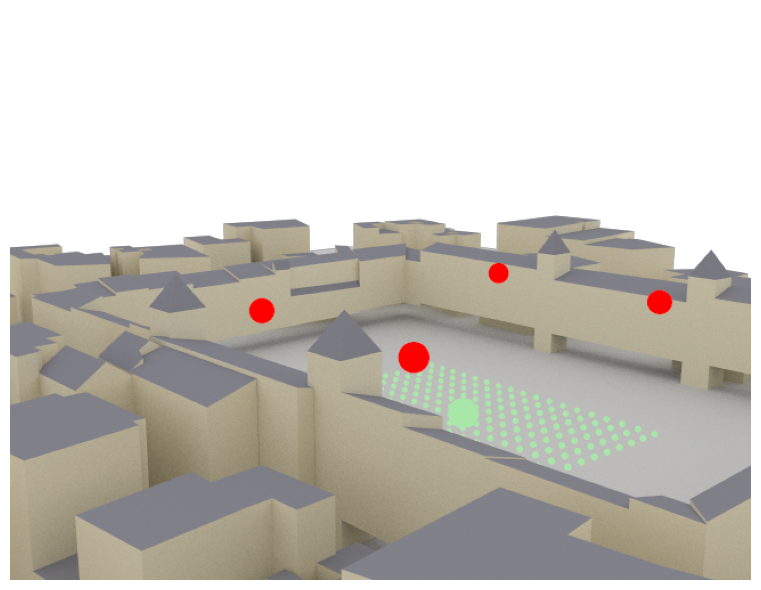

In [26]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-100,100,50], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

## 9. Run Ray Tracing
Compute all propagation paths between transmitters and receivers.

In [10]:
paths_scene_caso1 = p_solver(scene=scene, **solver_params)

## 10. Extract Channel Impulse Response (CIR)
Obtain complex channel coefficients `a` and delays `tau` for all TX-RX pairs.

In [11]:
#CIR 
#CASO 1
a_c1, tau_c1 = paths_scene_caso1.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a_c1.shape)
num_paths_c1 = a_c1.shape[4]
print("Num of possible paths from tx to rx: ", num_paths_c1)
# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau_c1.shape)



Shape of a:  (334, 2, 4, 1, 61, 1)
Num of possible paths from tx to rx:  61
Shape of tau:  (334, 2, 4, 1, 61)


FINGERPRINTS DE TRAINING, DEL GRID SEARCH RX 

## 11. Generate Training Fingerprints
For each grid receiver, compute the channel gain (in dB) from each transmitter. This forms the fingerprint vector.

In [12]:
fingerprints_grid = []
positions_grid = []

for rx_index, rx in enumerate(receptores_grid):
    fp_rx = []
    for tx_index in range(a_c1.shape[2]):
        a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
        channel_gain = np.sum(np.abs(a_rt)**2)
        fp_rx.append(10 * np.log10(channel_gain + 1e-12))
    fingerprints_grid.append(fp_rx)
    positions_grid.append(np.array(rx.position))

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)

print(fingerprints_grid)

[[ -86.30385   -96.80032   -86.83869   -82.331245]
 [ -86.93012   -86.206245  -88.117836  -83.64455 ]
 [ -90.05098   -99.361176  -87.127945  -83.71074 ]
 [ -86.97612   -86.28991   -87.04929   -83.98262 ]
 [ -86.73163   -83.58013   -87.37538   -84.35146 ]
 [ -86.22669   -89.76455   -87.379105  -84.552155]
 [ -84.06546   -89.63314   -82.93828   -84.98272 ]
 [ -84.90544  -100.68566   -83.77059   -85.14398 ]
 [ -85.70206   -90.62611   -83.50087   -85.3934  ]
 [ -82.2163    -84.757614  -86.25855   -85.61104 ]
 [ -83.08406   -87.55569   -86.39446   -86.45067 ]
 [ -82.933945  -84.59311   -86.912766  -83.43826 ]
 [ -85.24578   -83.06302   -86.47904   -85.431854]
 [ -87.034515  -94.59296   -87.409485  -82.472755]
 [ -86.13563  -102.00064   -87.33266   -83.67242 ]
 [ -85.38629   -97.92285   -88.14061   -84.20101 ]
 [ -86.866264 -101.48584   -87.130875  -84.10272 ]
 [ -86.60091   -85.90451   -88.77128   -83.75595 ]
 [ -84.663666  -89.414894  -87.449905  -84.57496 ]
 [ -83.43486   -85.06118   -83.

INGERPRINTS DE TESTING, DE LOS 100 RX A ESTIMAR POSICION

## 12. Generate Test Fingerprints
Same process for test receivers. Note: `offset` is used to access the correct indices in the path array.

In [13]:
fingerprints_test = []
positions_test = []

offset = len(receptores_grid)

for i, rx in enumerate(receptores_test):
    rx_index = offset + i
    fp_rx = []
    for tx_index in range(a_c1.shape[2]):
        a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
        channel_gain = np.sum(np.abs(a_rt)**2)
        fp_rx.append(10 * np.log10(channel_gain + 1e-12))
    fingerprints_test.append(fp_rx)
    positions_test.append(np.array(rx.position))

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)

print(fingerprints_test)

[[-78.594086 -92.944916 -74.35542  -89.961464]
 [-85.22018  -83.76969  -82.842865 -84.79553 ]
 [-77.12367  -84.90012  -75.30745  -89.94635 ]
 [-73.77637  -81.42412  -76.52532  -81.00929 ]
 [-80.808876 -84.47255  -77.95487  -84.44034 ]
 [-81.545906 -83.5902   -82.96901  -85.94937 ]
 [-83.49792  -89.94132  -76.03082  -84.14058 ]
 [-79.59641  -83.964874 -82.148674 -86.33033 ]
 [-84.9994   -86.35556  -88.54454  -83.716446]
 [-78.828575 -84.192535 -78.36049  -96.61806 ]
 [-74.11448  -81.1902   -79.99417  -82.44378 ]
 [-75.555885 -83.73684  -77.34098  -91.95767 ]
 [-78.21628  -92.85437  -74.4982   -90.08553 ]
 [-83.76782  -85.8244   -79.255325 -84.096306]
 [-82.99984  -83.40558  -81.70089  -85.698395]
 [-86.451    -84.51325  -87.874954 -84.468735]
 [-80.96726  -83.571335 -79.45873  -85.12831 ]
 [-82.17056  -85.17287  -78.20425  -84.861404]
 [-77.30883  -82.09301  -82.75198  -82.781456]
 [-75.458435 -88.766014 -74.88704  -80.06764 ]
 [-80.87754  -89.06475  -73.453    -91.36281 ]
 [-81.84514  

Ejecucion de 100 test 

## 13. Position Estimation (kNN) & Results
Estimate positions using k-Nearest Neighbors. Compare fingerprint distances, select k closest matches, and average their positions. Results shown as CDF and Mean/Median error plots.

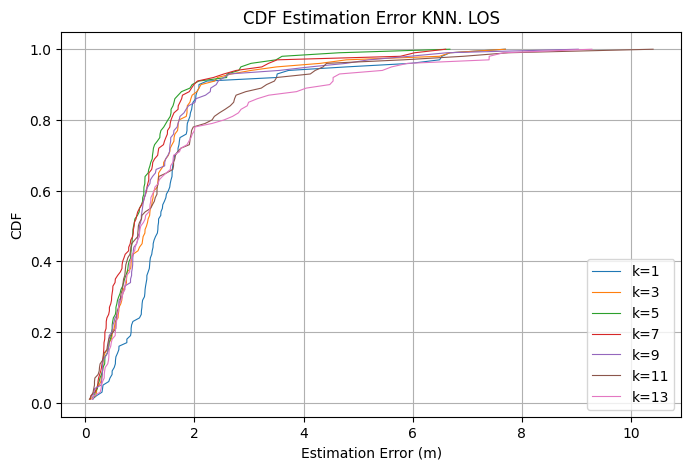

In [13]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. LOS")
plt.grid(True)
plt.legend()
plt.show()


Resultados finales

In [14]:
errores = np.array(errores)

print("===== RESULTS =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")


===== RESULTS =====
Mean Error: 1.729 m
Median Error: 1.042 m
Maximum Error: 9.284 m
Minimum Error: 0.131 m


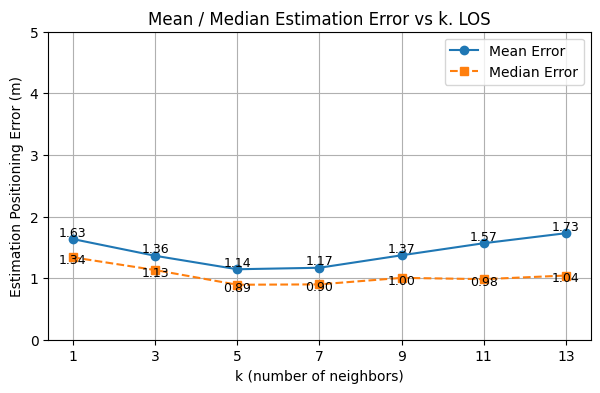

In [16]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. LOS")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


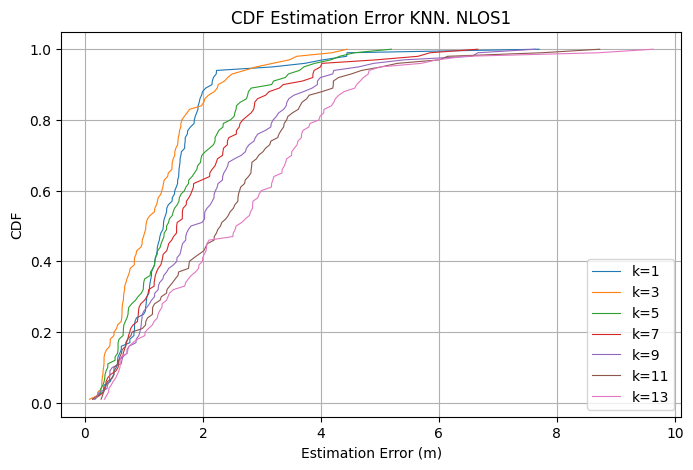

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS1")
plt.grid(True)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.show()



In [15]:
errores = np.array(errores)

print("===== RESULTS NLOS1 =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS NLOS1 =====
Mean Error: 2.664 m
Median Error: 2.611 m
Maximum Error: 9.631 m
Minimum Error: 0.331 m


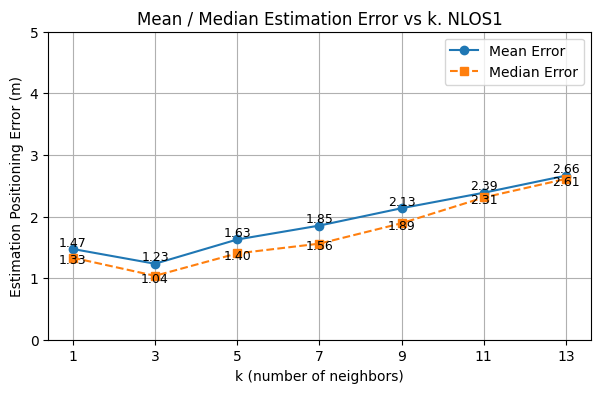

In [31]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS1")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


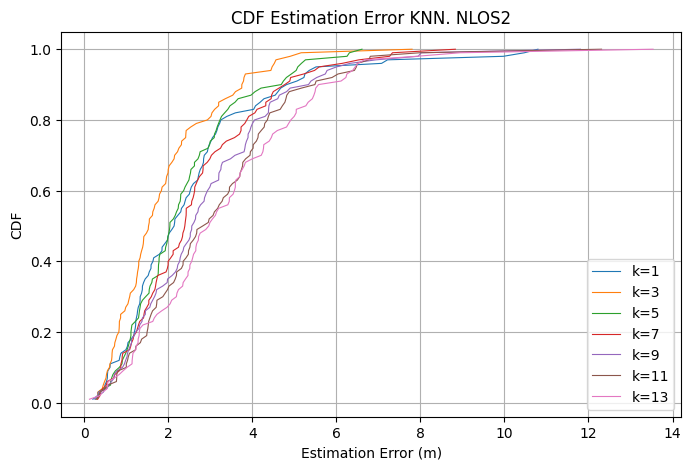

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS2")
plt.grid(True)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.show()


In [15]:
errores = np.array(errores)

print("===== RESULTS NLOS2 =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS NLOS2 =====
Mean Error: 3.319 m
Median Error: 2.978 m
Maximum Error: 13.538 m
Minimum Error: 0.126 m


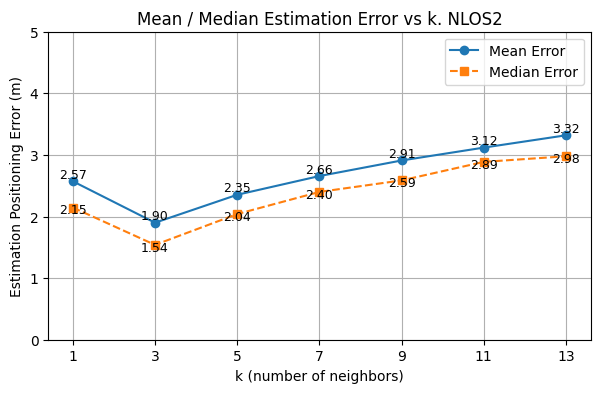

In [17]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS2")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


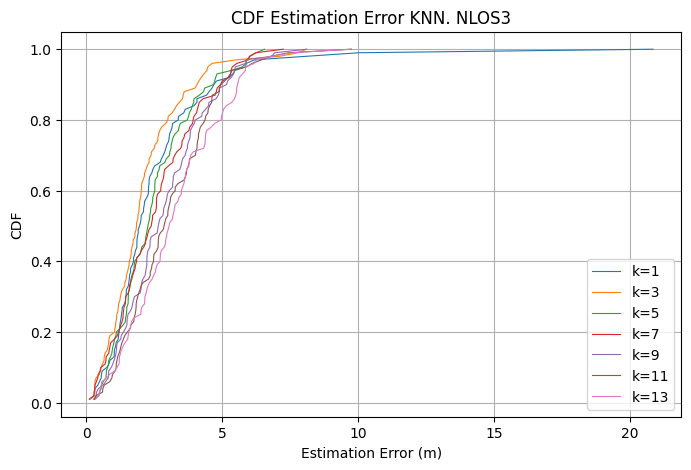

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS3")
plt.grid(True)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.show()


In [15]:
errores = np.array(errores)

print("===== RESULTS NLOS3 =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS NLOS3 =====
Mean Error: 3.260 m
Median Error: 3.066 m
Maximum Error: 9.726 m
Minimum Error: 0.346 m


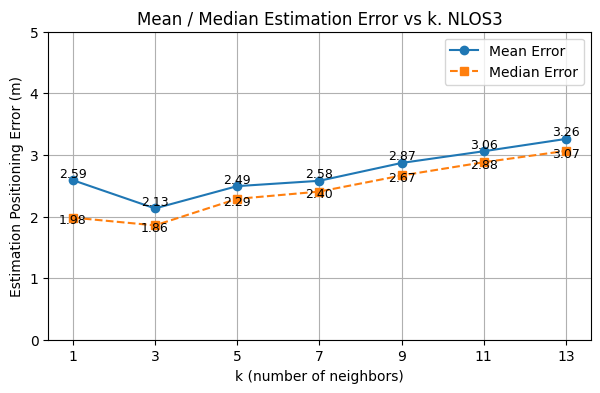

In [17]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS3")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


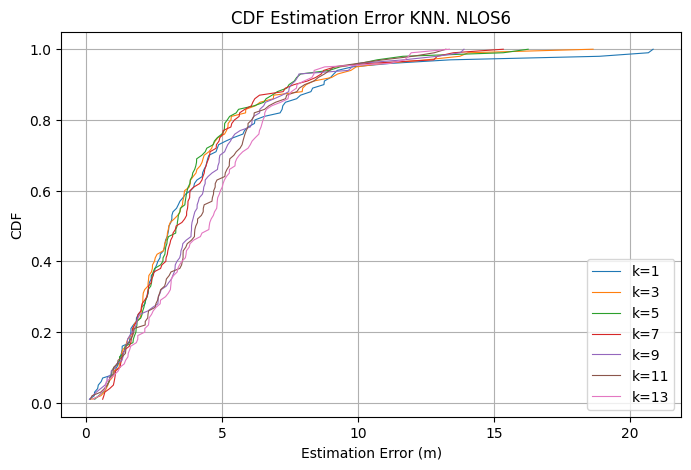

In [18]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS6")
plt.grid(True)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.show()


In [19]:
errores = np.array(errores)

print("===== RESULTS NLOS6 =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")


===== RESULTS NLOS6 =====
Mean Error: 4.593 m
Median Error: 4.544 m
Maximum Error: 13.366 m
Minimum Error: 0.267 m


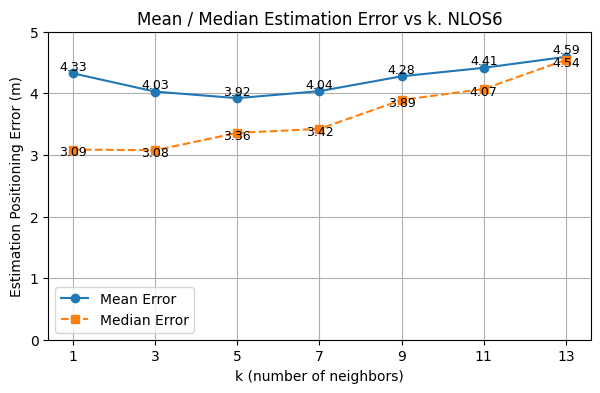

In [20]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS6")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


MAXDEPTH=10

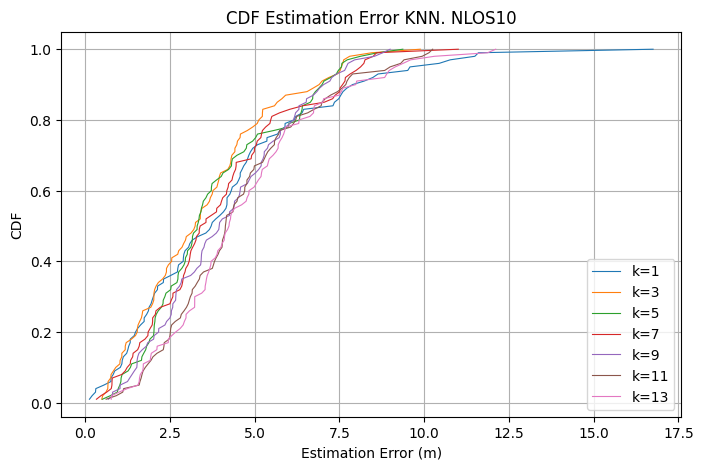

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS10")
plt.grid(True)
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))
plt.show()


In [15]:
errores = np.array(errores)

print("===== RESULTS NLOS10 =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")


===== RESULTS NLOS10 =====
Mean Error: 4.680 m
Median Error: 4.250 m
Maximum Error: 12.111 m
Minimum Error: 0.771 m


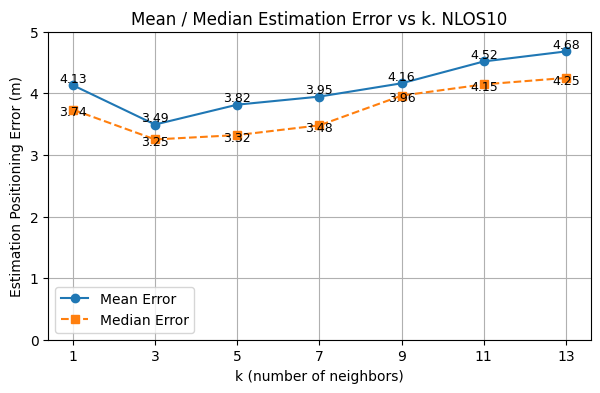

In [16]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS10")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))
# 🔹 Fijar límites eje Y
plt.ylim(0, 5) 
plt.show()


**RADIO MAP TO IMPROVE MULTIPATH ESTIMATION**

In [24]:
from sionna.rt import RadioMapSolver

rm_solver = RadioMapSolver()

rm = rm_solver(
    scene=scene,
    max_depth=5,
    cell_size=[0.5, 0.5],
    samples_per_tx=2*10**2
)


In [25]:
# Mapa de path gain: [num_tx, Ny, Nx]
# En este ejemplo, asumimos 1 transmisor
rm_pg = rm.path_gain.numpy()[0]  # forma [Ny, Nx]


In [26]:
import numpy as np

def position_to_radio_map_indices(pos, rm, map_shape):
    """
    Convierte coordenadas (x,y,z) a índices (iy,ix) del Radio Map.
    """
    # rm.cell_centers puede ser un tensor de varias dimensiones, lo aplanamos
    centers = np.array(rm.cell_centers)      # ej: shape (num_cells, 2, 3)
    centers = centers.reshape(-1, 3)         # ahora shape (num_cells_total, 3)
    
    xy_centers = centers[:, :2]              # solo X e Y, shape (num_cells_total, 2)
    
    # Distancia al receptor
    dists = np.linalg.norm(xy_centers - np.array(pos[:2]), axis=1)
    
    # Índice de celda más cercana
    cell_idx = np.argmin(dists)
    
    # Convertir flat index a (iy, ix)
    Ny, Nx = map_shape
    iy = cell_idx // Nx
    ix = cell_idx % Nx
    
    return iy, ix




In [27]:
fingerprints_grid = []
positions_grid = []

Ny, Nx = rm_pg.shape

for rx in receptores_grid:
    x, y, z = [rx.position[i].numpy().item() for i in range(3)]
    iy, ix = position_to_radio_map_indices([x, y, z], rm, (Ny, Nx))
    pg = rm_pg[iy, ix]
    fingerprints_grid.append([pg])
    positions_grid.append([x, y, z])

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)
print(fingerprints_grid)

[[9.37682820e-10]
 [7.34310251e-11]
 [2.07901890e-10]
 [1.96365035e-10]
 [9.05804376e-10]
 [2.85605095e-10]
 [2.67332351e-10]
 [3.11137893e-10]
 [4.53343224e-10]
 [4.88951213e-10]
 [5.33905031e-10]
 [6.19280793e-10]
 [8.36917313e-10]
 [9.60902122e-11]
 [2.42957154e-10]
 [3.13719217e-10]
 [2.86899143e-10]
 [3.39879763e-10]
 [4.36045617e-08]
 [4.26599395e-10]
 [1.25851912e-07]
 [3.69848180e-10]
 [5.00907094e-10]
 [6.11506290e-10]
 [6.55515031e-10]
 [8.42634851e-10]
 [3.67593400e-10]
 [2.95936911e-08]
 [5.32841049e-10]
 [3.12120718e-10]
 [5.18273868e-10]
 [6.31904140e-10]
 [5.60194446e-10]
 [5.91305338e-10]
 [4.51587129e-10]
 [5.50498647e-10]
 [5.88934290e-10]
 [8.49845472e-10]
 [8.60861105e-10]
 [7.64429076e-10]
 [6.61226518e-10]
 [6.02965344e-10]
 [6.73690714e-10]
 [7.18627380e-10]
 [8.44505799e-10]
 [1.02574960e-09]
 [2.57007429e-07]
 [1.11734988e-09]
 [1.17338195e-09]
 [1.21101307e-09]
 [9.88130688e-10]
 [1.17388810e-09]
 [1.10090392e-09]
 [1.03808395e-09]
 [1.18277921e-09]
 [1.658370

In [28]:
fingerprints_test = []
positions_test = []

Ny, Nx = rm_pg.shape

for rx in receptores_test:
    x, y, z = [rx.position[i].numpy().item() for i in range(3)]
    iy, ix = position_to_radio_map_indices([x, y, z], rm, (Ny, Nx))
    pg = rm_pg[iy, ix]
    fingerprints_test.append([pg])
    positions_test.append([x, y, z])

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)
print(fingerprints_test)

[[2.39399220e-08]
 [2.00874095e-09]
 [2.48591192e-08]
 [3.70389763e-08]
 [6.69703759e-09]
 [7.55391216e-09]
 [2.14155005e-09]
 [1.38802703e-08]
 [6.02965344e-10]
 [1.29447919e-08]
 [7.22514031e-08]
 [3.68734341e-08]
 [3.53178500e-08]
 [3.06302628e-09]
 [5.11924414e-09]
 [2.97307789e-10]
 [9.65357216e-09]
 [6.62995925e-09]
 [3.45295810e-08]
 [2.93598603e-08]
 [1.24245716e-08]
 [3.63676755e-09]
 [3.61439270e-08]
 [6.86514028e-08]
 [2.31443646e-08]
 [5.71257652e-10]
 [3.17679891e-08]
 [3.31122818e-09]
 [1.33468445e-08]
 [4.85127138e-08]
 [2.41226914e-08]
 [4.38326282e-08]
 [1.43138923e-08]
 [1.04836850e-07]
 [1.31009192e-09]
 [6.50119236e-10]
 [5.31289430e-08]
 [4.51097021e-10]
 [4.46933113e-09]
 [6.95098201e-10]
 [2.52311537e-07]
 [1.07960094e-08]
 [7.57891030e-08]
 [1.76983117e-09]
 [2.90366797e-09]
 [1.13109067e-07]
 [4.49581030e-08]
 [3.70535460e-08]
 [7.21423365e-10]
 [2.06173190e-09]
 [3.18403650e-08]
 [3.44899886e-10]
 [7.05939307e-09]
 [4.64434997e-08]
 [1.96995664e-08]
 [3.181660

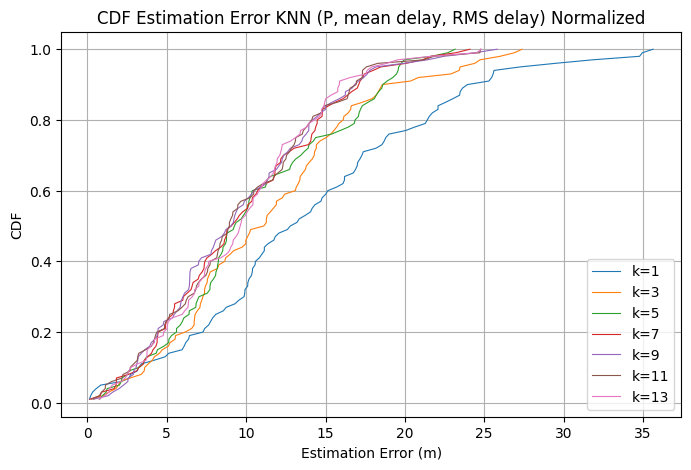

In [29]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# ===============================
# Calcular desviaciones típicas de cada feature (para normalización)
# ===============================
# fingerprints_grid.shape = (N_grid, 12) porque 4 TX * 3 features
sigma_features = np.std(fingerprints_grid, axis=0) + 1e-12  # evitar división por cero

# ===============================
# Función KNN usando distancia normalizada por dispersión (Mahalanobis diagonal)
# ===============================
def knn_estimate_normalized(query_fp, X_train, Y_train, k, sigma):
    # Distancia normalizada
    diff = (X_train - query_fp) / sigma
    distancias = np.linalg.norm(diff, axis=1)
    
    # Ajustar k si hay menos vecinos
    k_use = min(k, len(distancias))
    
    # Índices de los k vecinos más cercanos
    idx_knn = np.argsort(distancias)[:k_use]
    
    # Posición estimada = promedio de posiciones de los vecinos
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# ===============================
# Calcular errores para todos los k
# ===============================
errores_por_k = {k: [] for k in ks}

for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate_normalized(query_fp, fingerprints_grid, positions_grid, k, sigma_features)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# ===============================
# Crear la gráfica CDF
# ===============================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN (P, mean delay, RMS delay) Normalized")
plt.grid(True)
plt.legend(loc='lower right')  # siempre abajo a la derecha
plt.show()


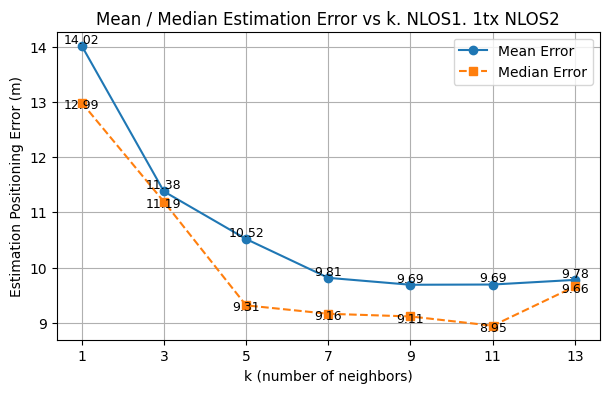

In [30]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS1. 1tx NLOS2")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, 14, 2))

plt.show()


RADIO MAP MEJORADO

In [31]:
from sionna.rt import RadioMapSolver
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# RADIO MAP CONFIGURACIÓN MEJORADA
# =====================================================

rm_solver = RadioMapSolver()

rm = rm_solver(
    scene=scene,
    max_depth=5,
    cell_size=[0.5, 0.5],      # 🔥 Más resolución espacial
    samples_per_tx=2*10**6     # 🔥 Menos ruido Monte Carlo
)

# Path gain → shape [num_tx, Ny, Nx]
rm_pg = rm.path_gain.numpy()

num_tx, Ny, Nx = rm_pg.shape
print("Radio map shape:", rm_pg.shape)

Radio map shape: (4, 602, 702)


In [32]:
def bilinear_interpolation(x, y, rm, rm_pg):
    centers = np.array(rm.cell_centers).reshape(-1, 3)
    centers_xy = centers[:, :2]

    # Obtener grid X,Y únicos
    xs = np.unique(centers_xy[:, 0])
    ys = np.unique(centers_xy[:, 1])

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    # Índices flotantes
    ix = (x - xs[0]) / dx
    iy = (y - ys[0]) / dy

    ix0 = int(np.floor(ix))
    iy0 = int(np.floor(iy))

    ix1 = min(ix0 + 1, Nx - 1)
    iy1 = min(iy0 + 1, Ny - 1)

    wx = ix - ix0
    wy = iy - iy0

    fingerprint = []

    for tx in range(num_tx):

        Q11 = rm_pg[tx, iy0, ix0]
        Q21 = rm_pg[tx, iy0, ix1]
        Q12 = rm_pg[tx, iy1, ix0]
        Q22 = rm_pg[tx, iy1, ix1]

        value = (
            Q11 * (1-wx)*(1-wy) +
            Q21 * wx*(1-wy) +
            Q12 * (1-wx)*wy +
            Q22 * wx*wy
        )

        fingerprint.append(value)

    return fingerprint

In [33]:
fingerprints_grid = []
positions_grid = []

for rx in receptores_grid:

    x, y, z = [rx.position[i].numpy().item() for i in range(3)]

    fp = bilinear_interpolation(x, y, rm, rm_pg)

    fingerprints_grid.append(fp)
    positions_grid.append([x, y, z])

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)

print("Fingerprint grid shape:", fingerprints_grid.shape)

Fingerprint grid shape: (234, 4)


In [34]:
fingerprints_test = []
positions_test = []

for rx in receptores_test:

    x, y, z = [rx.position[i].numpy().item() for i in range(3)]

    fp = bilinear_interpolation(x, y, rm, rm_pg)

    fingerprints_test.append(fp)
    positions_test.append([x, y, z])

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)

In [35]:
sigma_features = np.std(fingerprints_grid, axis=0) + 1e-12

In [36]:
def knn_estimate_normalized(query_fp, X_train, Y_train, k, sigma):

    diff = (X_train - query_fp) / sigma
    dist = np.linalg.norm(diff, axis=1)

    k_use = min(k, len(dist))
    idx = np.argsort(dist)[:k_use]

    return np.mean(Y_train[idx], axis=0)

In [37]:
ks = [1, 3, 5, 7, 9, 11]
errores_por_k = {k: [] for k in ks}

for i in range(len(fingerprints_test)):

    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]

    for k in ks:
        pos_est = knn_estimate_normalized(
            query_fp,
            fingerprints_grid,
            positions_grid,
            k,
            sigma_features
        )

        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)

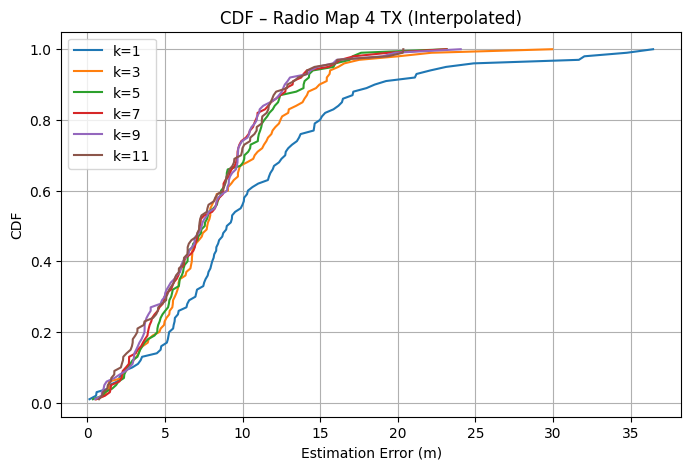

In [38]:
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.sort(errores_por_k[k])
    cdf = np.arange(1, len(errores)+1) / len(errores)
    plt.plot(errores, cdf, label=f'k={k}')

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF – Radio Map 4 TX (Interpolated)")
plt.grid(True)
plt.legend()
plt.show()

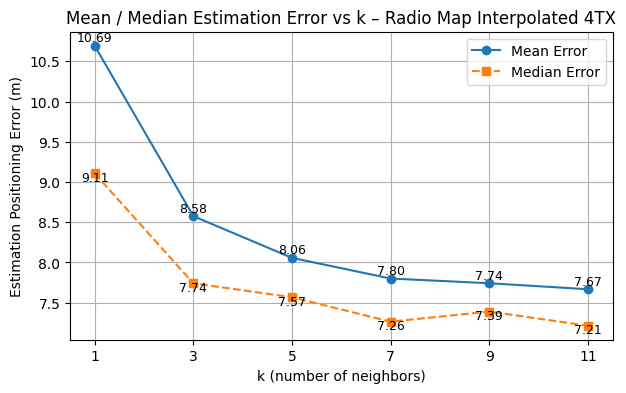

In [40]:
# ===============================
# Calcular error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# ===============================
# Graficar Mean / Median vs k
# ===============================
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Añadir etiquetas numéricas en cada punto (mean)
for k, err in zip(ks, mean_errors):
    plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)

# Añadir etiquetas numéricas en cada punto (median)
for k, err in zip(ks, median_errors):
    plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k – Radio Map Interpolated 4TX")
plt.grid(True)
plt.legend()
# 🔹 Forzar eje X con k impares
plt.xticks(range(1, max(ks)+2, 2))

plt.show()